In [57]:
from google.colab import files
uploaded = files.upload()

Saving SCN-Yamashita-wpd.csv to SCN-Yamashita-wpd (2).csv
Saving Leptin_plasma-Bodosi_1-wpd.csv to Leptin_plasma-Bodosi_1-wpd (2).csv
Saving Ghrelin_plasma-Bodosi_1-wpd.csv to Ghrelin_plasma-Bodosi_1-wpd (2).csv
Saving Ghrelin_hypothalamus-Bodosi_1-wpd.csv to Ghrelin_hypothalamus-Bodosi_1-wpd (2).csv


In [63]:
import pandas as pd

df_ghrelin_p = pd.read_csv('Ghrelin_plasma-Bodosi_1-wpd.csv')
df_ghrelin_h = pd.read_csv('Ghrelin_hypothalamus-Bodosi_1-wpd.csv')
df_leptin = pd.read_csv('Leptin_plasma-Bodosi_1-wpd.csv')
df_scn = pd.read_csv('SCN-Yamashita-wpd.csv')

data_list = [df_ghrelin_p, df_ghrelin_h, df_leptin, df_scn]

df_ghrelin_p.head()
df_ghrelin_h.head()
df_leptin.head()
df_scn.head()

,CT (hr),c-fos_positve_count
0,0,1103.997487
1,0,1276.313054
2,0,1295.000947
3,0,1346.904061
4,0,1475.621013


In [64]:
for i in data_list:
  i.head()        # first 5 rows
  i.columns       # column names
  i.shape         # (rows, columns)
  print(i)

         time      ghrelin
0    0.921296  1104.166667
1    4.881870  1854.166667
2    8.840203  1635.416667
3   12.886649  1187.500000
4   16.903226  1156.250000
5   20.933990   927.083333
6   24.864695  1093.750000
7   28.824522  1854.166667
8   32.853793  1645.833333
9   36.901732  1177.083333
10  40.918309  1145.833333
11  44.948327   927.083333
         time   ghrelin
0    0.998124  0.964706
1    4.975610  0.984314
2    8.953096  1.070588
3   13.005629  1.086275
4   17.058161  0.980392
5   21.035647  1.105882
6   25.013133  0.956863
7   29.065666  0.984314
8   32.968105  1.074510
9   37.020638  1.090196
10  41.073171  0.984314
11  45.050657  1.105882
         time    leptin
0    0.803530  2.551995
1    4.828856  2.235994
2    8.840478  3.065015
3   12.783576  3.619148
4   16.773819  6.234404
5   20.818331  4.315371
6   24.860651  2.579542
7   28.885429  2.309341
8   32.898147  3.046760
9   36.840697  3.646694
10  40.830940  6.261950
11  44.875452  4.342917
    CT (hr)  c-fos_positv

In [107]:
#singular cosine

import numpy as np

def cos_model(x, A, w, phi, C):
    return A * np.cos(w * x + phi) + C

from scipy.optimize import curve_fit

d_type = data_list[2]

guess_A = (max(d_type.iloc[:, 1]) - min(d_type.iloc[:, 1])) / 2
guess_C = np.mean(d_type.iloc[:, 1])
guess_w = 2 * np.pi / (d_type.iloc[:, 0].max() - d_type.iloc[:, 0].min())  # rough frequency
guess_phi = 0

params, _ = curve_fit(cos_model, d_type.iloc[:, 0], d_type.iloc[:, 1], p0=[guess_A, guess_w, guess_phi, guess_C])

A, w, phi, C = params

# smooth x for nice curve
x_fit = np.linspace(min(d_type.iloc[:, 0]), max(d_type.iloc[:, 0]), 500)
y_fit = cos_model(x_fit, A, w, phi, C)

In [115]:
# normalized time (only for ghrelin plasma)
# singular cosine

import numpy as np

def cos_model(x, A, w, phi, C):
    return A * np.cos(w * x + phi) + C

from scipy.optimize import curve_fit

d_type = data_list[1]

x = d_type.iloc[:, 0].values
y = d_type.iloc[:, 1].values

# sort
idx = np.argsort(x)
x = x[idx]
y = y[idx]

# normalize
x_mean, x_std = x.mean(), x.std()
x_norm = (x - x_mean) / x_std

guess_A = (y.max() - y.min()) / 2
guess_C = y.mean()
guess_w = 2 * np.pi  # good default after normalization
guess_phi = 0

params, _ = curve_fit(
    cos_model,
    x_norm,
    y,
    p0=[guess_A, guess_w, guess_phi, guess_C],
    maxfev=20000
)

A, w, phi, C = params

# smooth curve
x_fit = np.linspace(x.min(), x.max(), 500)
x_fit_norm = (x_fit - x_mean) / x_std
y_fit = cos_model(x_fit_norm, A, w, phi, C)

In [53]:
# @title
#fourier
d_type = data_list[0]

fft = np.fft.fft(d_type.iloc[:, 1])
freqs = np.fft.fftfreq(len(d_type.iloc[:, 0]), d=(d_type.iloc[:, 0][1]-d_type.iloc[:, 0][0]))

magnitude = np.abs(fft)
idx = np.argsort(magnitude)[-5:]   # top 5 frequencies
dominant_freqs = freqs[idx]
omega = 2 * np.pi * dominant_freqs

def model(x, A1, phi1, A2, phi2, C):
    return (A1*np.cos(omega[0]*x + phi1) +
            A2*np.cos(omega[1]*x + phi2) + C)

from scipy.optimize import curve_fit

guess = [1, 0, 1, 0, np.mean(d_type.iloc[:, 1])]

params, _ = curve_fit(model, d_type.iloc[:, 0], d_type.iloc[:, 1], p0=guess)

A1, phi1, A2, phi2, C = params

x_fit = np.linspace(min(d_type.iloc[:, 0]), max(d_type.iloc[:, 0]), 500)
y_fit = model(x_fit, A1, phi1, A2, phi2, C)

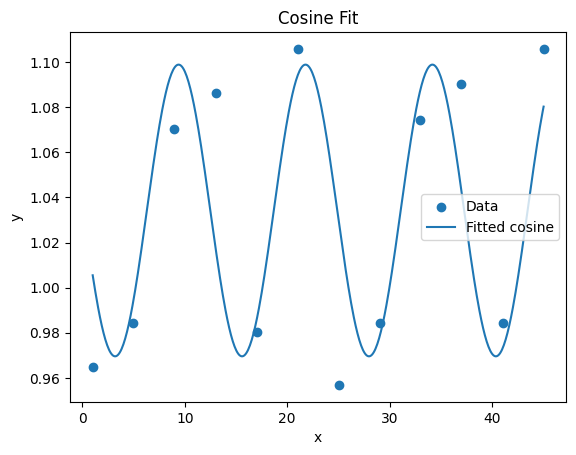

In [116]:
# plot the data and function
import numpy as np
import matplotlib.pyplot as plt

# plot
plt.scatter(d_type.iloc[:, 0], d_type.iloc[:, 1], label="Data")   # actual data
plt.plot(x_fit, y_fit, label="Fitted cosine")  # smooth curve

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Cosine Fit")
plt.show()


In [67]:
# @title
with open("my_model.py", "w") as f:
    f.write(f"""
import numpy as np

def model(x):
    return {A:.6f} * np.cos({w:.6f} * x + {phi:.6f}) + {C:.6f}
""")

[ 4.11635458e+02  2.65248261e-01 -1.94183153e+00  1.31190578e+03]


In [117]:
# @title
print(params)

[0.06468781 7.0077939  0.62327368 1.03423138]


In [125]:

def g_h(t):
  ghrelin_h = 4.11635458e+02 * np.cos(2.65248261e-01 * t - 1.94183153e+00) + 1.31190578e+03
  return ghrelin_h
def g_p(t):
  w_real = 7.0077939 / 13.829261660647743 #x.std()
  phi_real = 0.62327368 - (7.0077939 * 23.018136335209505 / 13.829261660647743)

  ghrelin_p = 0.06468781 * np.cos(w_real * t + phi_real) + 1.03423138
  return ghrelin_p
def l(t):
  leptin = 1.7132457 * np.cos(0.25891851 * t + 1.90885731) + 3.68477418
  return leptin
def s(t):
  c_fos = 4.97669924e+02 * np.cos(2.44009422e-01 * t - 9.08555848e-01) + 8.69592999e+02
  return c_fos


In [124]:
# @title
print(x.std())
print(x.mean())

13.829261660647743
23.018136335209505


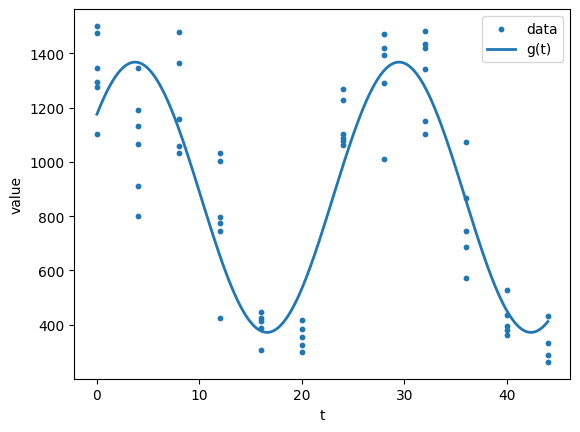

In [130]:
# @title
import matplotlib.pyplot as plt

d_type = data_list[3]

t = d_type.iloc[:, 0].values   # time
y = d_type.iloc[:, 1].values   # observed data

t_fit = np.linspace(t.min(), t.max(), 500)
y_fit = s(t_fit)

plt.scatter(t, y, label="data", s=10)     # raw data points
plt.plot(t_fit, y_fit, label="g(t)", linewidth=2)  # model curve

plt.legend()
plt.xlabel("t")
plt.ylabel("value")
plt.show()